In [13]:
import os
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler

from tools.tools import WAVELENGTH_INFO

def augment_curve_smooth(specs: np.ndarray, n_augments: int = 150, amplitude: float = 600.0,
                         n_knots: int = 5, random_state: int = None) -> np.ndarray:
    """
    针对输入的单条光谱曲线（shape=(1, 100)），生成 n_augments 条平滑扰动后的曲线，
    扰动为低频随机函数，波动幅度约为 amplitude（默认500）。

    参数:
        specs (np.ndarray): 原始光谱数据，形状为 (1, 100)。
        n_augments (int): 生成扰动曲线的数量，默认 100 条。
        amplitude (float): 扰动曲线总波动幅度，默认 500（即上下波动范围约为 ±250）。
        n_knots (int): 控制点的数量，决定扰动函数的平滑程度。较少的控制点会得到更低频的扰动。
        random_state (int): 随机数种子，保证结果可重复。

    返回:
        np.ndarray: 生成的扰动曲线数据，形状为 (n_augments, 100)。
    """
    if random_state is not None:
        np.random.seed(random_state)

    # 取原始曲线（假设 specs 的形状为 (1, 100)）
    original = specs[0]  # shape: (100,)
    n_points = original.shape[0]
    x_full = np.arange(n_points)

    augmented_curves = np.zeros((n_augments, n_points))

    # 定义控制点在原始曲线坐标下的位置
    knots_x = np.linspace(0, n_points - 1, n_knots)

    for i in range(n_augments):
        # 为每个控制点生成扰动值，范围为 [-amplitude/2, amplitude/2]
        knots_y = np.random.uniform(-amplitude / 2, amplitude / 2, n_knots)
        # 使用 cubic 插值生成平滑扰动曲线
        interp_func = interp1d(knots_x, knots_y, kind='cubic', fill_value="extrapolate")
        smooth_variation = interp_func(x_full)  # shape: (100,)

        # 将平滑扰动曲线叠加到原始曲线上
        new_curve = original + smooth_variation
        augmented_curves[i, :] = new_curve

    return augmented_curves


def preprocess_spectra(spectra: np.ndarray, wavelengths: np.ndarray) -> np.ndarray:
    """
    对光谱数据进行 SNV -> Savitzky-Golay 二阶导数 -> 均值中心化 预处理。

    参数:
        spectra (np.ndarray): 原始光谱数据，形状为 (n_samples, n_wavelengths)
        wavelengths (np.ndarray): 波长数组，形状为 (n_wavelengths,)

    返回:
        np.ndarray: 预处理后的光谱数据 (spectra_mc)，形状与输入相同
    """

    # Step 1: SNV（Standard Normal Variate）
    def snv(data):
        return (data - np.mean(data, axis=1, keepdims=True)) / np.std(data, axis=1, keepdims=True)

    spectra_snv = snv(spectra)

    # Step 2: Savitzky-Golay 滤波器，二阶导数（窗口长度9，2阶多项式）
    spectra_sg_deriv = savgol_filter(
        spectra_snv, window_length=9, polyorder=2, deriv=1, axis=1
    )

    # Step 3: 均值中心化（mean centering）
    scaler = StandardScaler(with_mean=True, with_std=False)
    spectra_mc = scaler.fit_transform(spectra_sg_deriv)

    return spectra_mc

In [14]:
def getFandMHsiData(num_f, f_start, num_m, m_start):
    f_path = r'D:\workspace\gdv-egg-model\Code_EggGenderDet\data_hlh_train_20250907_hy\Dataset\huayu_13d0h_all\female'
    m_path = r'D:\workspace\gdv-egg-model\Code_EggGenderDet\data_hlh_train_20250907_hy\Dataset\huayu_13d0h_all\male'
    f_files = []
    m_files = []

    for file in os.listdir(f_path):
        if f_start < num_f:
            if file.endswith(".txt"):
                file_path = os.path.join(f_path, file)
                f_files.append(file_path)
                f_start += 1
    for file in os.listdir(m_path):
        if m_start < num_m:
            if file.endswith(".txt"):
                file_path = os.path.join(m_path, file)
                m_files.append(file_path)
                m_start += 1
    return f_files, m_files

num_f, f_start = 2000, 0
num_m, m_start = 2000, 0
female_files, male_files = getFandMHsiData(num_f, f_start, num_m, m_start)

f_data_list = []
m_data_list = []

for file in female_files:
    with open(file, 'r') as f:
        f_data_list.append(np.array([list(map(float, line.strip().split())) for line in f]))
f_data_list = np.array(f_data_list)

for file in male_files:
    with open(file, 'r') as f:
        m_data_list.append(np.array([list(map(float, line.strip().split())) for line in f]))
m_data_list = np.array(m_data_list)

start_idx, end_idx = 100, 250
wavelengths = WAVELENGTH_INFO[start_idx:end_idx]
num_bands = len(wavelengths)  # 150
# test = f_data_list.reshape(f_data_list.shape[0], -1, num_bands)
# 计算每组的平均光谱
female_mean = np.mean(f_data_list.reshape(f_data_list.shape[0], -1, num_bands), axis=1)  # (200, 150)
male_mean = np.mean(m_data_list.reshape(m_data_list.shape[0], -1, num_bands), axis=1)  # (200, 150)

print(f"  female_mean shape: {female_mean.shape}")
print(f"  male_mean shape: {male_mean.shape}")

  female_mean shape: (2000, 150)
  male_mean shape: (2000, 150)


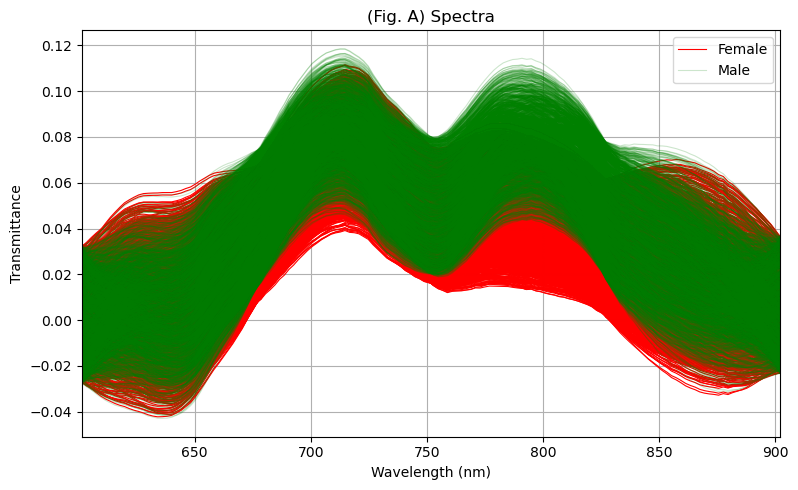

In [15]:
from matplotlib import pyplot as plt


window_size = 9  # 平滑窗口大小
window_size_d = 9  # 二阶导数窗口大小
polyorder = 2  # 多项式阶数

f_specs = augment_curve_smooth(female_mean, n_augments=num_f, random_state=42) / 1e4
m_specs = augment_curve_smooth(male_mean, n_augments=num_m, random_state=42) / 1e4

alpha_value_f = 1
alpha_value_m = 0.2
lw_val = 0.8

plt.figure(figsize=(8, 5))

# Female spectra (Blue)
for i in range(f_specs.shape[0]):
    if i == 0:
        plt.plot(wavelengths, f_specs[i], c="r", linewidth=lw_val, alpha=alpha_value_f, label="Female")
    else:
        plt.plot(wavelengths, f_specs[i], c="r", linewidth=lw_val, alpha=alpha_value_f)

# Male spectra (Red)

for i in range(m_specs.shape[0]):
    if i == 0:
        plt.plot(wavelengths, m_specs[i], c="g", linewidth=lw_val, alpha=alpha_value_m, label="Male")
    else:
        plt.plot(wavelengths, m_specs[i], c="g", linewidth=lw_val, alpha=alpha_value_m)

plt.title(f"(Fig. A) Spectra")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmittance")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
# plt.xlim([625, 775])
plt.xlim(wavelengths[0],wavelengths[-1])
plt.show()

spectra_f.shape=(2000, 150)
spectra_m.shape=(2000, 150)


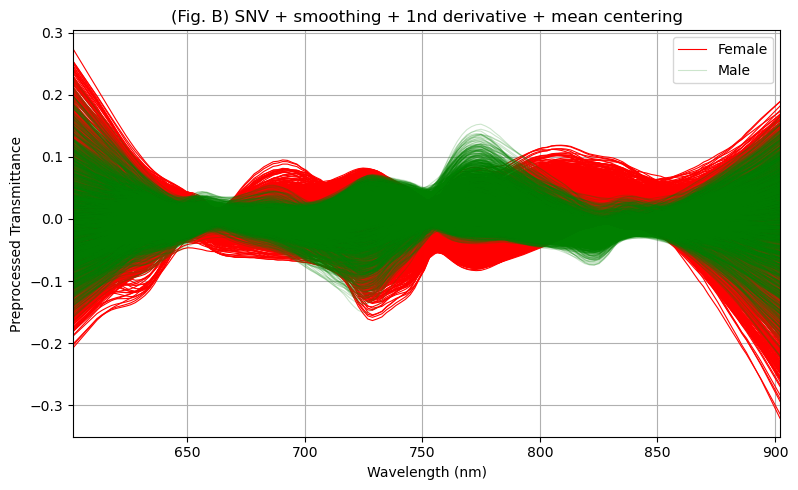

In [16]:
# 合并数据
all_specs = np.vstack([f_specs, m_specs])  # shape: (n_total_samples, n_wavelengths)

# 统一预处理
all_specs_processed = preprocess_spectra(all_specs, wavelengths)

# 拆分回来
spectra_f = all_specs_processed[:f_specs.shape[0], :]
spectra_m = all_specs_processed[f_specs.shape[0]:, :]

print(f"{spectra_f.shape=}")
print(f"{spectra_m.shape=}")

plt.figure(figsize=(8, 5))

# Female spectra in blue
for i in range(spectra_f.shape[0]):
    if i == 0:
        plt.plot(wavelengths, spectra_f[i], c="r", linestyle="-", linewidth=lw_val, alpha=alpha_value_f,
                 label="Female")
    else:
        plt.plot(wavelengths, spectra_f[i], c="r", linestyle="-", linewidth=lw_val, alpha=alpha_value_f)

# Male spectra in red
for i in range(spectra_m.shape[0]):
    if i == 0:
        plt.plot(wavelengths, spectra_m[i], c="g", linestyle="-", linewidth=lw_val, alpha=alpha_value_m,
                 label="Male")
    else:
        plt.plot(wavelengths, spectra_m[i], c="g", linestyle="-", linewidth=lw_val, alpha=alpha_value_m)

# Labels and style
plt.title(f"(Fig. B) SNV + smoothing + 1nd derivative + mean centering")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Preprocessed Transmittance")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
# plt.xlim([625, 775])
plt.xlim(wavelengths[0],wavelengths[-1])
plt.show()